In [1]:
import pandas as pd
import geopandas as gpd

exp = pd.read_csv("/Volumes/squirrel-utopia 1/national_wf_disaster_hosp/local_data/binary_exposures_by_zcta.csv")

zctas = gpd.read_file("/Volumes/squirrel-utopia 1/national_wf_disaster_hosp/local_data/zctas_2020.geojson")

<Axes: >

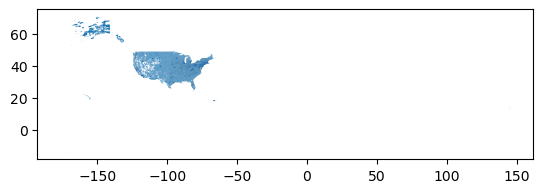

In [2]:
zctas.plot()

In [3]:
zctas.head()

,ID_admin_unit,geometry
0,35592,"MULTIPOLYGON (((-88.24735 33.6539, -88.24713 3..."
1,35616,"MULTIPOLYGON (((-88.13997 34.58184, -88.13995 ..."
2,35621,"MULTIPOLYGON (((-86.81659 34.3496, -86.81648 3..."
3,35651,"MULTIPOLYGON (((-87.53087 34.42492, -87.53082 ..."
4,36010,"MULTIPOLYGON (((-85.95712 31.67744, -85.95676 ..."


In [4]:
exp.head()

,ID_admin_unit,population,ghsl_used,month,exposed_main,exposed_smaller,exposed_larger,p_exp_main,p_exp_smaller,p_exp_larger,...,primary_unexposed_1,less_misclas_exposed_2,less_misclas_exposed_more_than_0_2,less_misclas_unexposed_2,larger_exposed_1,larger_exposed_more_than_0_1,larger_unexposed_1,smaller_exposed_1,smaller_exposed_more_than_0_1,smaller_unexposed_1
0,35592,5068,1,2000-01,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,35616,4123,1,2000-01,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,35621,2724,1,2000-01,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,35651,1219,1,2000-01,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,36010,4272,1,2000-01,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [5]:
summary = exp.groupby('ID_admin_unit').agg({
    'primary_exposed_1': 'sum',
    'larger_exposed_1': 'sum',
    'smaller_exposed_1': 'sum'
}).reset_index()

In [6]:
summary['ID_admin_unit'] = summary['ID_admin_unit'].astype(str)
zctas['ID_admin_unit'] = zctas['ID_admin_unit'].astype(str)

exp_geo = summary.merge(zctas, how='left')
exp_geo.head()

,ID_admin_unit,primary_exposed_1,larger_exposed_1,smaller_exposed_1,geometry
0,601,0.0,0.0,0.0,None
1,602,0.0,0.0,0.0,None
2,603,0.0,0.0,0.0,None
3,606,0.0,0.0,0.0,None
4,610,0.0,0.0,0.0,None


In [7]:
exp_geo = gpd.GeoDataFrame(exp_geo, geometry='geometry')
exp_geo_albers = exp_geo.to_crs(epsg=5070)

In [8]:
exclude_prefixes = (
    '006', '007', '008', '009',  # Puerto Rico & Virgin Islands
    '967', '968',                # Hawaii
    '969',                       # Guam & Northern Mariana Islands
    '995', '996', '997', '998', '999'  # Alaska
)
exp_geo_albers = exp_geo_albers[~exp_geo_albers['ID_admin_unit'].str.startswith(exclude_prefixes)]

In [9]:
import matplotlib.pyplot as plt

<Axes: >

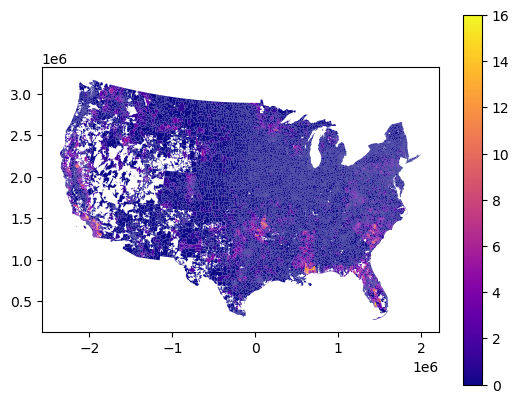

In [10]:
exp_geo_albers.plot(column='primary_exposed_1', cmap='plasma', legend=True)


<Axes: >

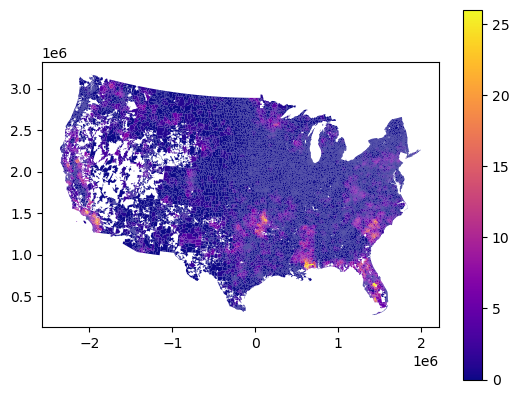

In [11]:
exp_geo_albers.plot(column='larger_exposed_1', cmap='plasma', legend=True)

<Axes: >

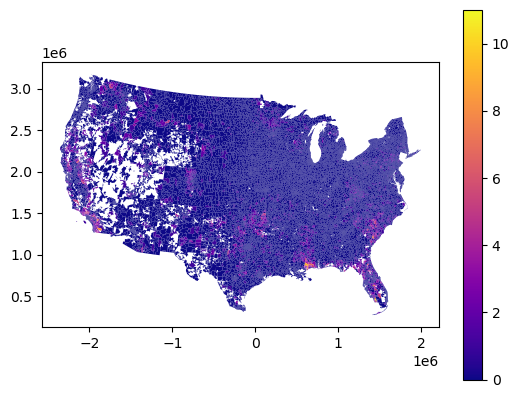

In [12]:
exp_geo_albers.plot(column='smaller_exposed_1', cmap='plasma', legend=True)

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [14]:
exp['year'] = exp['month'].astype(str).str[:4]

summary = exp.groupby(['ID_admin_unit', 'year']).agg({
    'primary_exposed_1': 'sum',
    'larger_exposed_1': 'sum',
    'smaller_exposed_1': 'sum'
}).reset_index()

In [15]:
summary['ID_admin_unit'] = summary['ID_admin_unit'].astype(str)
zctas['ID_admin_unit'] = zctas['ID_admin_unit'].astype(str)

exp_geo = summary.merge(zctas, how='left')
exp_geo.head()

,ID_admin_unit,year,primary_exposed_1,larger_exposed_1,smaller_exposed_1,geometry
0,601,2000,0.0,0.0,0.0,None
1,601,2001,0.0,0.0,0.0,None
2,601,2002,0.0,0.0,0.0,None
3,601,2003,0.0,0.0,0.0,None
4,601,2004,0.0,0.0,0.0,None


In [16]:
exp_geo = gpd.GeoDataFrame(exp_geo, geometry='geometry')
exp_geo_albers = exp_geo.to_crs(epsg=5070)

In [17]:
exclude_prefixes = (
    '006', '007', '008', '009',  # Puerto Rico & Virgin Islands
    '967', '968',                # Hawaii
    '969',                       # Guam & Northern Mariana Islands
    '995', '996', '997', '998', '999'  # Alaska
)
exp_geo_albers = exp_geo_albers[~exp_geo_albers['ID_admin_unit'].str.startswith(exclude_prefixes)]

In [ ]:
import matplotlib.pyplot as plt
import os

years = sorted(exp_geo_albers['year'].unique())
output_dir = "/Volumes/squirrel-utopia 1/national_wf_disaster_hosp/figures/yearly_zcta_level_count_of_exposures"

for year in years:
    fig, ax = plt.subplots(figsize=(10, 8))
    df_year = exp_geo_albers[exp_geo_albers['year'] == year]
    df_year.plot(column='primary_exposed_1', cmap='plasma', legend=True, ax=ax)
    ax.set_title(f"Wildfire Exposure - Year: {year}")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/wildfire_exposure_{year}.png", dpi=150)
    plt.close(fig)

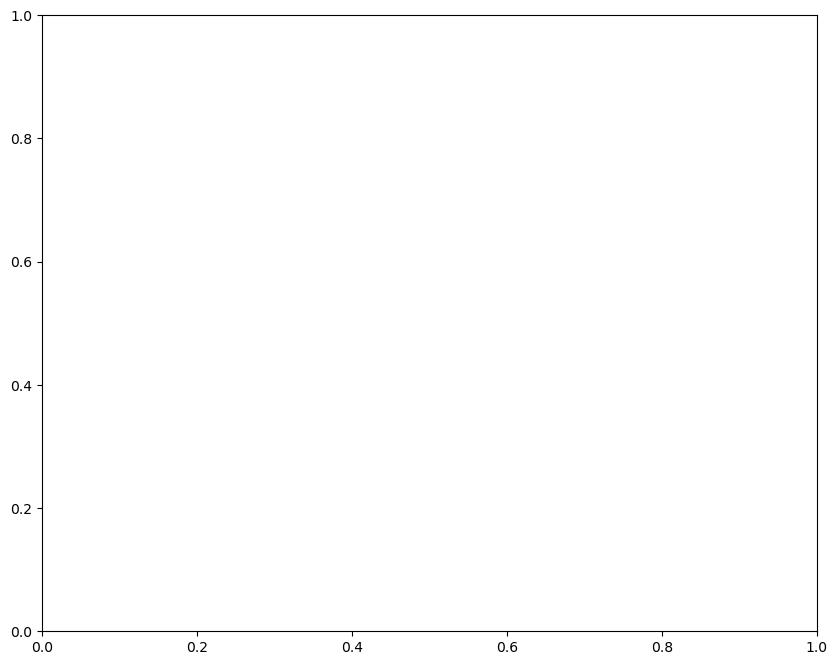

In [47]:
# Assume exp_geo_albers has columns: ID_admin_unit, geometry, n_exp, year
years = sorted(exp_geo_albers['year'].unique())
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame):
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.clear()

    df_year = exp_geo_albers[exp_geo_albers['year'] == years[frame]]
    df_year.plot(column='primary_exposed_1', cmap='plasma', legend=True, ax=ax)
    ax.set_title(f"Wildfire Exposure - Year: {years[frame]}")
    if ax.get_legend() is not None:
        ax.get_legend().remove()

ani = FuncAnimation(fig, update, frames=len(years), repeat=False)
plt.show()

# To save as GIF (requires imageio or pillow)
ani.save("/Volumes/squirrel-utopia 1/national_wf_disaster_hosp/figures/wildfire_exposure.gif", writer='pillow', fps = 4)